In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set(style="whitegrid")

In [3]:
data_path = '../data/processed_disaster_data.csv'
df = pd.read_csv(data_path)
df.head()

,year,country,disaster_type,deaths,affected,damage
0,2008,Brazil,Wildfire,98,9944,3949087
1,2019,Japan,Flood,48,5320,4436200
2,2014,USA,Hurricane,33,6124,1331559
3,2021,Brazil,Earthquake,55,41036,91403697
4,2004,China,Earthquake,256,38788,13737752


In [4]:
df_encoded = pd.get_dummies(df, columns=['disaster_type', 'country'], drop_first=True)

# Example: create target variable 'high_risk' based on deaths or damage
df_encoded['high_risk'] = (df_encoded['deaths'] > df_encoded['deaths'].median()).astype(int)

# Drop original numeric target columns if needed
df_encoded = df_encoded.drop(['deaths', 'damage', 'affected'], axis=1)
df_encoded.head()

,year,disaster_type_Earthquake,disaster_type_Flood,disaster_type_Hurricane,disaster_type_Tsunami,disaster_type_Wildfire,country_Brazil,country_China,country_India,country_Japan,country_Mexico,country_USA,high_risk
0,2008,False,False,False,False,True,True,False,False,False,False,False,0
1,2019,False,True,False,False,False,False,False,False,True,False,False,0
2,2014,False,False,True,False,False,False,False,False,False,False,True,0
3,2021,True,False,False,False,False,True,False,False,False,False,False,0
4,2004,True,False,False,False,False,False,True,False,False,False,False,1


In [5]:
X = df_encoded.drop('high_risk', axis=1)
y = df_encoded['high_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC
y_prob = rf.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[70 30]
 [25 75]]

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.70      0.72       100
           1       0.71      0.75      0.73       100

    accuracy                           0.72       200
   macro avg       0.73      0.72      0.72       200
weighted avg       0.73      0.72      0.72       200

ROC-AUC: 0.8349500000000001


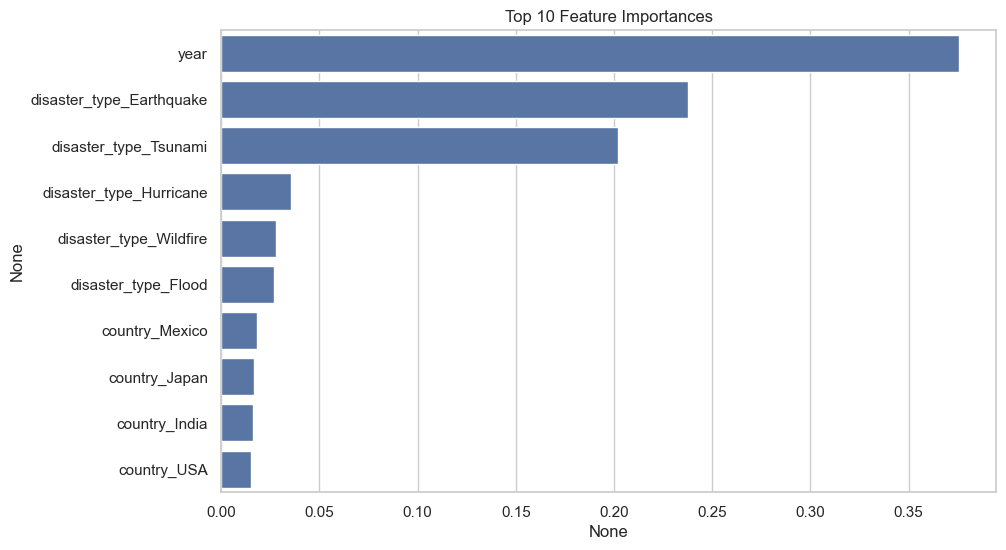

In [7]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances[:10], y=importances.index[:10])
plt.title('Top 10 Feature Importances')
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/feature_importance.png', bbox_inches='tight')
plt.show()
plt.close()

In [8]:
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.75      0.94      0.84       100
           1       0.92      0.69      0.79       100

    accuracy                           0.81       200
   macro avg       0.84      0.81      0.81       200
weighted avg       0.84      0.81      0.81       200

